# Reproducción en PyTorch del ejemplo numérico PI-VAE

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana_05_PI_VAE.ipynb)


Este notebook reproduce el caso numérico de la Sección 3.1 del artículo **“A Physics-Informed Variational Autoencoder for Modeling Power Plant Thermal Systems”**.

El objetivo es comparar:

1. un **VAE estándar**, entrenado solo con pérdida de reconstrucción y divergencia KL;
2. un **PI-VAE**, que agrega pérdidas físicas construidas a partir de las ecuaciones diferenciales parciales indicadas en el artículo.

In [17]:
import copy
import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.set_default_dtype(torch.float32)

Device: cpu


## Generación de datos: 

Definimos un sistema no lineal de seis variables como:

$$
\begin{aligned}
x_1 &= \gamma + e_1, \\
x_2 &= 0.3\gamma^2 + 0.5\gamma + e_2, \\
x_3 &= 0.4\gamma^2 - 1.6\gamma - 0.4 + e_3, \\
x_4 &= -x_2 + 0.25 + e_4, \\
x_5 &= \gamma^3 + \cos(\gamma^2) + e_5, \\
x_6 &= 4\sin(\gamma) + 0.4\gamma^3 + \gamma + e_6.
\end{aligned}
$$

con

$$
\gamma \sim U(0,3), \qquad e_i \sim \mathcal{N}(0, 0.02).
$$

In [18]:
def generate_data(n: int, seed=None) -> torch.Tensor:
    """Genera datos del sistema no lineal de la ecuación (31)."""
    if seed is not None:
        g = torch.Generator().manual_seed(seed)
        gamma = torch.rand(n, 1, generator=g) * 3.0
        noise = lambda: torch.randn(n, 1, generator=g) * math.sqrt(0.02)
    else:
        gamma = torch.rand(n, 1) * 3.0
        noise = lambda: torch.randn(n, 1) * math.sqrt(0.02)

    x1 = gamma + noise()
    x2 = 0.3 * gamma**2 + 0.5 * gamma + noise()
    x3 = 0.4 * gamma**2 - 1.6 * gamma - 0.4 + noise()
    x4 = -x2 + 0.25 + noise()
    x5 = gamma**3 + torch.cos(gamma**2) + noise()
    x6 = 4 * torch.sin(gamma) + 0.4 * gamma**3 + gamma + noise()

    return torch.cat([x1, x2, x3, x4, x5, x6], dim=1)

X_train_raw = generate_data(20, seed=SEED).to(device)
X_test_raw = generate_data(2000, seed=SEED + 1).to(device)

X_train_raw.shape, X_test_raw.shape

(torch.Size([20, 6]), torch.Size([2000, 6]))

## Normalización

Normalizaremos las variables. Esto es fundamental porque $x_5$ y $x_6$ tienen rangos mucho mayores que $x_1$, $x_2$, $x_3$ y $x_4$.

Usamos media y desviación estándar calculadas **solo con el conjunto de entrenamiento**:

$$
\tilde{x}_j = \frac{x_j - \mu_j}{\sigma_j}.
$$

Las pérdidas de reconstrucción se calculan en coordenadas normalizadas, pero las pérdidas físicas se formulan en coordenadas originales, porque las ecuaciones físicas están escritas en variables $x_j$.

In [19]:
x_mean = X_train_raw.mean(dim=0, keepdim=True)
x_std = X_train_raw.std(dim=0, keepdim=True) + 1e-8


def normalize(x: torch.Tensor) -> torch.Tensor:
    return (x - x_mean) / x_std


def unnormalize(x_norm: torch.Tensor) -> torch.Tensor:
    return x_norm * x_std + x_mean

X_train = normalize(X_train_raw)
X_test = normalize(X_test_raw)

print("Media train raw:", x_mean.detach().cpu().numpy().round(3))
print("Std train raw  :", x_std.detach().cpu().numpy().round(3))

Media train raw: [[ 1.151  1.175 -1.486 -0.933  4.404  5.366]]
Std train raw  : [[0.833 1.013 0.491 1.007 5.383 3.451]]


## Modelo VAE

El VAE codifica cada muestra $x$ en una distribución gaussiana latente:

$$
q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x)I).
$$

Luego usa el truco de reparametrización:

$$
z = \mu + \sigma \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,I).
$$

Finalmente, el decoder reconstruye:

$$
\hat{x} = D_\theta(z).
$$

En este ejemplo conviene usar un espacio latente **unidimensional**. La razón es que los datos fueron generados a partir de un único factor oculto, $\gamma$, de modo que imponer la física sobre un latente 1D hace mucho más clara la interpretación de derivadas como

$$
\frac{\partial \hat{x}_i}{\partial \hat{x}_1}.
$$

In [20]:
class VAE(nn.Module):
    """VAE con arquitectura 6-16-8-1-8-16-6."""

    def __init__(self, input_dim: int = 6, latent_dim: int = 1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
        )
        self.mu = nn.Linear(8, latent_dim)
        self.logvar = nn.Linear(8, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z

    def reconstruct_deterministic(self, x: torch.Tensor) -> torch.Tensor:
        """Reconstrucción usando z=mu. Es más estable para evaluar métricas."""
        mu, _ = self.encode(x)
        return self.decode(mu)

## Pérdida VAE

La pérdida del VAE es el negativo del ELBO:

$$
L_{VAE} = L_{rec} + \beta L_{prior}.
$$

Usamos MSE como pérdida de reconstrucción:

$$
L_{rec} = \frac{1}{N}\sum_i \lVert x^{(i)} - \hat{x}^{(i)} \rVert_2^2.
$$

La divergencia KL contra una normal estándar es:

$$
D_{KL}\left(q_\phi(z|x) \Vert \mathcal{N}(0,I)\right)
= -\frac{1}{2}\sum_k \left(1 + \log \sigma_k^2 - \mu_k^2 - \sigma_k^2\right).
$$

In [21]:
def vae_loss(x: torch.Tensor, x_hat: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta: float = 0.1):
    recon = F.mse_loss(x_hat, x)
    kl = -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())
    total = recon + beta * kl
    return total, {"recon": recon.detach(), "kl": kl.detach()}

## Derivadas físicas vía espacio latente

El paper calcula derivadas entre variables reconstruidas usando la dependencia común respecto del vector latente $z$. Para el caso numérico, necesitamos derivadas de la forma:

$$
\frac{\partial \hat{x}_i}{\partial \hat{x}_1}.
$$

En esta versión usamos un latente **1D**, consistente con el hecho de que el sistema fue generado por un único factor $\gamma$. Entonces la regla de cadena se simplifica a:

$$
\frac{\partial \hat{x}_i}{\partial \hat{x}_1}
=
\frac{\partial \hat{x}_i / \partial z}{\partial \hat{x}_1 / \partial z}.
$$

Esta formulación es más estable e interpretable que sumar razones componente a componente en un latente multidimensional.

En código agregamos una estabilización numérica para evitar divisiones por valores cercanos a cero.

In [22]:
def grad_wrt_z(y: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    """Gradiente dy/dz para un batch. Requiere create_graph=True para backpropagar la pérdida física."""
    return torch.autograd.grad(
        y,
        z,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
        allow_unused=False,
    )[0]


def safe_divide(numerator: torch.Tensor, denominator: torch.Tensor, eps: float = 1e-4) -> torch.Tensor:
    """División estabilizada que conserva el signo del denominador."""
    sign = torch.where(denominator >= 0, torch.ones_like(denominator), -torch.ones_like(denominator))
    denom = torch.where(denominator.abs() < eps, eps * sign, denominator)
    return numerator / denom


def derivative_wrt_x1_norm(x_hat_norm: torch.Tensor, z: torch.Tensor, output_index: int) -> torch.Tensor:
    """Calcula d x_i_norm / d x_1_norm asumiendo un latente 1D."""
    if z.shape[1] != 1:
        raise ValueError(
            "Esta formulación física asume latent_dim=1. "
            "Para latent_dim>1 haría falta otra definición de d x_i / d x_1."
        )

    xi = x_hat_norm[:, output_index:output_index + 1]
    x1 = x_hat_norm[:, 0:1]

    dxi_dz = grad_wrt_z(xi, z)
    dx1_dz = grad_wrt_z(x1, z)

    return safe_divide(dxi_dz, dx1_dz)

## Pérdida física en coordenadas originales

Las restricciones completas del **Modelo 9** de la Tabla 3 son:

$$
\frac{\partial x_2}{\partial x_1} - 0.5 - 0.6x_1 = 0,
$$

$$
\frac{\partial x_3}{\partial x_1} - 0.8x_1 + 1.6 = 0,
$$

$$
\frac{\partial x_4}{\partial x_1} + 0.5 + 0.6x_1 = 0,
$$

$$
\frac{\partial x_5}{\partial x_1} - 3x_1^2 + 2x_1\sin(x_1^2) = 0,
$$

$$
\frac{\partial x_6}{\partial x_1} - 4\cos(x_1) - 1.2x_1^2 - 1 = 0.
$$

Como el decoder produce $\tilde{x}$, convertimos primero a variables originales:

$$
\hat{x}_j = \sigma_j \hat{\tilde{x}}_j + \mu_j.
$$

Además, por cambio de escala:

$$
\frac{\partial x_i}{\partial x_1}
=
\frac{\sigma_i}{\sigma_1}
\frac{\partial \tilde{x}_i}{\partial \tilde{x}_1}.
$$

En la práctica, los residuales no tienen todos la misma escala. Por eso reescalamos cada ecuación por una magnitud típica de su término derecho, para que $r_5$ y $r_6$ no dominen toda la optimización.

In [23]:
def pde_loss_model9_raw(
    x_hat_norm: torch.Tensor,
    z: torch.Tensor,
    x_mean: torch.Tensor,
    x_std: torch.Tensor,
    residual_scale_bias: float = 1.0,
):
    """Pérdida PDE del Modelo 9, evaluada en coordenadas originales."""
    x_hat_raw = x_hat_norm * x_std + x_mean
    x1 = x_hat_raw[:, 0:1]

    # Conversión de derivadas normalizadas a derivadas en coordenadas originales.
    scale = x_std / x_std[:, 0:1]

    dx2_dx1 = scale[:, 1:2] * derivative_wrt_x1_norm(x_hat_norm, z, 1)
    dx3_dx1 = scale[:, 2:3] * derivative_wrt_x1_norm(x_hat_norm, z, 2)
    dx4_dx1 = scale[:, 3:4] * derivative_wrt_x1_norm(x_hat_norm, z, 3)
    dx5_dx1 = scale[:, 4:5] * derivative_wrt_x1_norm(x_hat_norm, z, 4)
    dx6_dx1 = scale[:, 5:6] * derivative_wrt_x1_norm(x_hat_norm, z, 5)

    rhs_terms = {
        "r2": 0.5 + 0.6 * x1,
        "r3": 0.8 * x1 - 1.6,
        "r4": -0.5 - 0.6 * x1,
        "r5": 3.0 * x1**2 - 2.0 * x1 * torch.sin(x1**2),
        "r6": 4.0 * torch.cos(x1) + 1.2 * x1**2 + 1.0,
    }

    residuals = {
        "r2": dx2_dx1 - rhs_terms["r2"],
        "r3": dx3_dx1 - rhs_terms["r3"],
        "r4": dx4_dx1 - rhs_terms["r4"],
        "r5": dx5_dx1 - rhs_terms["r5"],
        "r6": dx6_dx1 - rhs_terms["r6"],
    }

    scaled_residuals = {
        name: residuals[name] / (rhs.abs().mean().detach() + residual_scale_bias)
        for name, rhs in rhs_terms.items()
    }

    loss = sum(torch.mean(r.pow(2)) for r in scaled_residuals.values())
    diagnostics = {name: torch.mean(torch.abs(r)).detach() for name, r in residuals.items()}
    diagnostics["scaled_pde_mse"] = loss.detach()
    return loss, diagnostics

## Muestras sintéticas en el espacio latente

El artículo usa Latin Hypercube Sampling en el espacio latente y transforma los puntos para que sigan una normal estándar. Implementamos esa idea con `torch.erfinv`, usando la identidad:

$$
\Phi^{-1}(u) = \sqrt{2}\,\operatorname{erf}^{-1}(2u-1).
$$

Estas muestras sintéticas $z_s$ no tienen pérdida de reconstrucción; solo se usan para ampliar la cobertura de la pérdida física:

$$
\hat{x}_s = D_\theta(z_s).
$$

In [24]:
def lhs_standard_normal(n_samples: int, latent_dim: int, device: torch.device) -> torch.Tensor:
    """Latin Hypercube Sampling transformado a N(0, I)."""
    cols = []
    for _ in range(latent_dim):
        perm = torch.randperm(n_samples, device=device).float()
        u = (perm + torch.rand(n_samples, device=device)) / n_samples
        u = u.clamp(1e-6, 1 - 1e-6)
        z_col = math.sqrt(2.0) * torch.erfinv(2.0 * u - 1.0)
        cols.append(z_col.unsqueeze(1))
    return torch.cat(cols, dim=1).requires_grad_(True)

## Pérdida PI-VAE

La pérdida total del PI-VAE es:

$$
L_{PI\text{-}VAE}
= L_{rec} + \beta L_{prior} + w(t)\left(\alpha_1 L^{d}_{phy} + \alpha_2 L^{s}_{phy}\right).
$$

Donde:

- $L^{d}_{phy}$: pérdida física sobre reconstrucciones de datos reales;
- $L^{s}_{phy}$: pérdida física sobre muestras sintéticas generadas desde el espacio latente;
- $w(t)$: un **warmup** que hace crecer el peso físico gradualmente;
- $\alpha_1$, $\alpha_2$, $\beta$: pesos de balanceo.

Dos decisiones prácticas ayudan bastante en este ejemplo:

1. calcular la física de datos con `z = mu`, no con una muestra ruidosa;
2. arrancar con $\alpha_1$ y $\alpha_2$ pequeños y aumentarlos con warmup.

In [25]:
@dataclass
class TrainConfig:
    latent_dim: int = 1
    beta: float = 0.1
    alpha1: float = 0.003
    alpha2: float = 0.006
    lr: float = 1e-3
    pivae_lr: float = 3e-4
    pretrain_epochs: int = 3000
    pivae_epochs: int = 3000
    alpha_warmup_epochs: int = 1500
    synthetic_samples: int = 128
    residual_scale_bias: float = 1.0
    print_every: int = 500


def pi_vae_loss(
    model: VAE,
    x_norm: torch.Tensor,
    x_hat_norm: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    z: torch.Tensor,
    cfg: TrainConfig,
    epoch: int,
):
    base, base_logs = vae_loss(x_norm, x_hat_norm, mu, logvar, beta=cfg.beta)

    # Para la física sobre datos reales usamos z=mu, evitando ruido de muestreo.
    z_phy = mu
    x_phy_norm = model.decode(z_phy)
    phy_data, phy_data_logs = pde_loss_model9_raw(
        x_phy_norm,
        z_phy,
        x_mean,
        x_std,
        residual_scale_bias=cfg.residual_scale_bias,
    )

    z_syn = lhs_standard_normal(cfg.synthetic_samples, cfg.latent_dim, device=x_norm.device)
    x_syn_norm = model.decode(z_syn)
    phy_syn, phy_syn_logs = pde_loss_model9_raw(
        x_syn_norm,
        z_syn,
        x_mean,
        x_std,
        residual_scale_bias=cfg.residual_scale_bias,
    )

    warmup = min(1.0, epoch / cfg.alpha_warmup_epochs)
    total = base + warmup * (cfg.alpha1 * phy_data + cfg.alpha2 * phy_syn)
    logs = {
        "total": total.detach(),
        "vae": base.detach(),
        "recon": base_logs["recon"],
        "kl": base_logs["kl"],
        "phy_data": phy_data.detach(),
        "phy_syn": phy_syn.detach(),
        "warmup": torch.tensor(warmup, device=x_norm.device),
    }
    logs.update({f"data_{k}": v for k, v in phy_data_logs.items()})
    logs.update({f"syn_{k}": v for k, v in phy_syn_logs.items()})
    return total, logs

## Métricas de evaluación

Usamos las mismas métricas del paper:

$$
RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\sum_{j=1}^{n}(x_j^{(i)} - \hat{x}_j^{(i)})^2}
$$

$$
R^2 = 1 -
\frac{\sum_{i=1}^{N}\sum_{j=1}^{n}(x_j^{(i)} - \hat{x}_j^{(i)})^2}
{\sum_{i=1}^{N}\sum_{j=1}^{n}(x_j^{(i)} - \bar{x}_j)^2}.
$$

Para evaluar reconstrucción usamos `z = mu`, sin ruido latente, porque da una medición más estable.

In [26]:
def compute_metrics(x: torch.Tensor, x_hat: torch.Tensor) -> dict[str, float]:
    mse = torch.mean((x - x_hat) ** 2)
    rmse = torch.sqrt(mse)
    x_bar = x.mean(dim=0, keepdim=True)
    ss_res = torch.sum((x - x_hat) ** 2)
    ss_tot = torch.sum((x - x_bar) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return {"rmse": float(rmse.detach().cpu()), "r2": float(r2.detach().cpu())}


def evaluate_reconstruction(model: VAE) -> dict[str, dict[str, float]]:
    model.eval()
    with torch.no_grad():
        train_hat_norm = model.reconstruct_deterministic(X_train)
        test_hat_norm = model.reconstruct_deterministic(X_test)
        train_hat_raw = unnormalize(train_hat_norm)
        test_hat_raw = unnormalize(test_hat_norm)

    return {
        "train_norm": compute_metrics(X_train, train_hat_norm),
        "test_norm": compute_metrics(X_test, test_hat_norm),
        "train_raw": compute_metrics(X_train_raw, train_hat_raw),
        "test_raw": compute_metrics(X_test_raw, test_hat_raw),
    }


def print_metrics(title: str, metrics: dict[str, dict[str, float]]) -> None:
    print(title)
    for split, vals in metrics.items():
        print(f"  {split:10s} RMSE={vals['rmse']:.4f}  R2={vals['r2']:.4f}")

## Entrenamiento: etapa 1, VAE estándar

Primero entrenamos un VAE sin restricciones físicas. Esta etapa corresponde al preentrenamiento del algoritmo del paper y también sirve como baseline.

Un buen diagnóstico inicial es que el VAE pueda reconstruir razonablemente bien las 20 muestras de entrenamiento. Si esto falla, no conviene agregar todavía la pérdida física.

In [27]:
def train_vae_only(model: VAE, cfg: TrainConfig) -> list[dict[str, float]]:
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    history = []
    for epoch in range(1, cfg.pretrain_epochs + 1):
        model.train()
        x_hat, mu, logvar, z = model(X_train)
        loss, logs = vae_loss(X_train, x_hat, mu, logvar, beta=cfg.beta)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if epoch == 1 or epoch % cfg.print_every == 0:
            row = {"epoch": epoch, "loss": float(loss.detach().cpu()), **{k: float(v.cpu()) for k, v in logs.items()}}
            history.append(row)
            print(f"VAE epoch {epoch:5d} | loss={row['loss']:.5f} | recon={row['recon']:.5f} | kl={row['kl']:.5f}")
    return history

cfg = TrainConfig()
vae_model = VAE(latent_dim=cfg.latent_dim).to(device)
vae_history = train_vae_only(vae_model, cfg)
vae_state = copy.deepcopy(vae_model.state_dict())

print_metrics("\nMétricas VAE baseline", evaluate_reconstruction(vae_model))

VAE epoch     1 | loss=0.97073 | recon=0.96964 | kl=0.01088
VAE epoch   500 | loss=0.38724 | recon=0.28479 | kl=1.02453
VAE epoch  1000 | loss=0.26628 | recon=0.13590 | kl=1.30375
VAE epoch  1500 | loss=0.24541 | recon=0.11549 | kl=1.29929
VAE epoch  2000 | loss=0.19284 | recon=0.05356 | kl=1.39281
VAE epoch  2500 | loss=0.18790 | recon=0.03883 | kl=1.49070
VAE epoch  3000 | loss=0.22104 | recon=0.07833 | kl=1.42714

Métricas VAE baseline
  train_norm RMSE=0.1465  R2=0.9774
  test_norm  RMSE=0.1925  R2=0.9735
  train_raw  RMSE=0.2342  R2=0.9921
  test_raw   RMSE=0.3249  R2=0.9918


## Entrenamiento: etapa 2, fine-tuning PI-VAE

Partimos del VAE preentrenado y agregamos las restricciones físicas de manera gradual. En esta versión hacemos tres cambios para no destruir la reconstrucción demasiado rápido:

- usamos `latent_dim=1`, acorde al generador real del problema;
- la física sobre datos reales se calcula con `mu`, no con una muestra latente ruidosa;
- los pesos físicos crecen con `warmup` y además usamos un `learning rate` menor en el fine-tuning.

Si el entrenamiento se vuelve inestable, reducir `alpha1`, `alpha2` o aumentar `alpha_warmup_epochs`.

In [28]:
def train_pivae(model: VAE, cfg: TrainConfig) -> list[dict[str, float]]:
    opt = torch.optim.Adam(model.parameters(), lr=cfg.pivae_lr)
    history = []
    for epoch in range(1, cfg.pivae_epochs + 1):
        model.train()
        x_hat, mu, logvar, z = model(X_train)
        loss, logs = pi_vae_loss(model, X_train, x_hat, mu, logvar, z, cfg, epoch=epoch)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        opt.step()

        if epoch == 1 or epoch % cfg.print_every == 0:
            row = {"epoch": epoch, **{k: float(v.cpu()) for k, v in logs.items()}}
            history.append(row)
            print(
                f"PI-VAE epoch {epoch:5d} | total={row['total']:.5f} | vae={row['vae']:.5f} "
                f"| phy_data={row['phy_data']:.5f} | phy_syn={row['phy_syn']:.5f} | warmup={row['warmup']:.3f}"
            )
    return history

pivae_model = VAE(latent_dim=cfg.latent_dim).to(device)
pivae_model.load_state_dict(vae_state)
pivae_history = train_pivae(pivae_model, cfg)

print_metrics("\nMétricas PI-VAE", evaluate_reconstruction(pivae_model))

PI-VAE epoch     1 | total=0.21412 | vae=0.21412 | phy_data=0.19308 | phy_syn=0.72892 | warmup=0.001
PI-VAE epoch   500 | total=0.30452 | vae=0.30374 | phy_data=0.17422 | phy_syn=0.30288 | warmup=0.333
PI-VAE epoch  1000 | total=0.20777 | vae=0.20649 | phy_data=0.11830 | phy_syn=0.25947 | warmup=0.667
PI-VAE epoch  1500 | total=0.19200 | vae=0.19050 | phy_data=0.14865 | phy_syn=0.17650 | warmup=1.000
PI-VAE epoch  2000 | total=0.19937 | vae=0.19783 | phy_data=0.18598 | phy_syn=0.16295 | warmup=1.000
PI-VAE epoch  2500 | total=0.21021 | vae=0.20893 | phy_data=0.10226 | phy_syn=0.16239 | warmup=1.000
PI-VAE epoch  3000 | total=0.22404 | vae=0.22278 | phy_data=0.09232 | phy_syn=0.16516 | warmup=1.000

Métricas PI-VAE
  train_norm RMSE=0.1467  R2=0.9774
  test_norm  RMSE=0.1983  R2=0.9718
  train_raw  RMSE=0.2483  R2=0.9911
  test_raw   RMSE=0.3699  R2=0.9894


## Comparación VAE vs PI-VAE

El paper reporta que el VAE estándar suele tener peor generalización en test, mientras que el PI-VAE mejora al imponer restricciones físicas. Sin embargo, eso no ocurre automáticamente: si la pérdida física domina demasiado, el modelo puede ganar consistencia física pero perder reconstrucción.

Con la configuración ajustada de esta notebook, lo esperable es observar:

- alta reconstrucción en train para ambos modelos;
- un PI-VAE con residual físico claramente menor;
- una reconstrucción de test comparable o mejor que la del baseline, siempre que el balanceo de pérdidas sea razonable.

In [29]:
vae_metrics = evaluate_reconstruction(vae_model)
pivae_metrics = evaluate_reconstruction(pivae_model)

print_metrics("VAE", vae_metrics)
print()
print_metrics("PI-VAE", pivae_metrics)

VAE
  train_norm RMSE=0.1465  R2=0.9774
  test_norm  RMSE=0.1925  R2=0.9735
  train_raw  RMSE=0.2342  R2=0.9921
  test_raw   RMSE=0.3249  R2=0.9918

PI-VAE
  train_norm RMSE=0.1467  R2=0.9774
  test_norm  RMSE=0.1983  R2=0.9718
  train_raw  RMSE=0.2483  R2=0.9911
  test_raw   RMSE=0.3699  R2=0.9894


## Residuos físicos

Además de RMSE y $R^2$, conviene medir si las salidas reconstruidas satisfacen las ecuaciones físicas. Para eso calculamos el promedio absoluto de cada residual del Modelo 9.

También reportamos `scaled_pde_mse`, que es la versión reescalada de la pérdida física usada durante entrenamiento.

In [32]:
def physics_residual_report(model: VAE, x_norm: torch.Tensor, name: str) -> dict[str, float]:
    model.eval()
    # No usamos torch.no_grad(), porque necesitamos autograd para derivadas respecto de z.
    mu, _ = model.encode(x_norm)
    z = mu.detach().clone().requires_grad_(True)
    x_hat_norm = model.decode(z)
    loss, logs = pde_loss_model9_raw(
        x_hat_norm,
        z,
        x_mean,
        x_std,
        residual_scale_bias=cfg.residual_scale_bias,
    )
    report = {k: float(v.detach().cpu()) for k, v in logs.items()}
    report["pde_mse_total"] = float(loss.detach().cpu())
    print(name)
    for k, v in report.items():
        print(f"  {k:15s}: {v:.6f}")
    return report

vae_phys = physics_residual_report(vae_model, X_test, "Residual físico VAE - test")
print()
pivae_phys = physics_residual_report(pivae_model, X_test, "Residual físico PI-VAE - test")

Residual físico VAE - test
  r2             : 0.278188
  r3             : 0.307442
  r4             : 0.262134
  r5             : 1.681198
  r6             : 0.866460
  scaled_pde_mse : 0.323557
  pde_mse_total  : 0.323557

Residual físico PI-VAE - test
  r2             : 0.197554
  r3             : 0.230530
  r4             : 0.180537
  r5             : 1.285249
  r6             : 0.567357
  scaled_pde_mse : 0.105663
  pde_mse_total  : 0.105663


## Gráficos de dispersión: verdadero vs reconstruido

Estos gráficos son análogos a la inspección visual de la Figura 5 del paper: puntos cercanos a la diagonal indican buena reconstrucción.

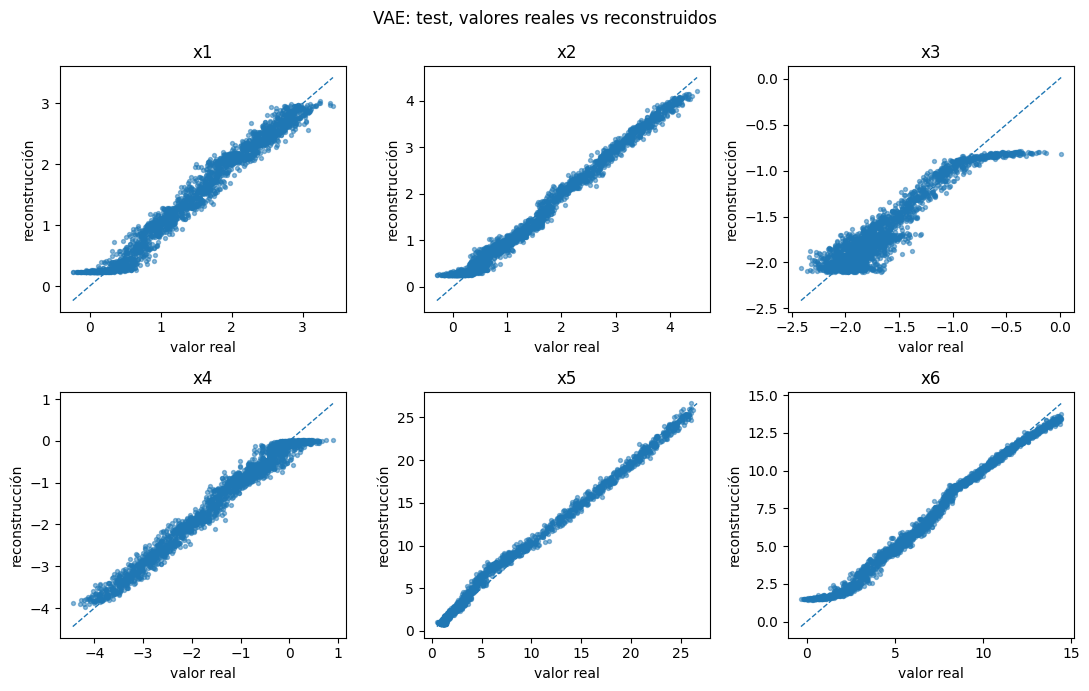

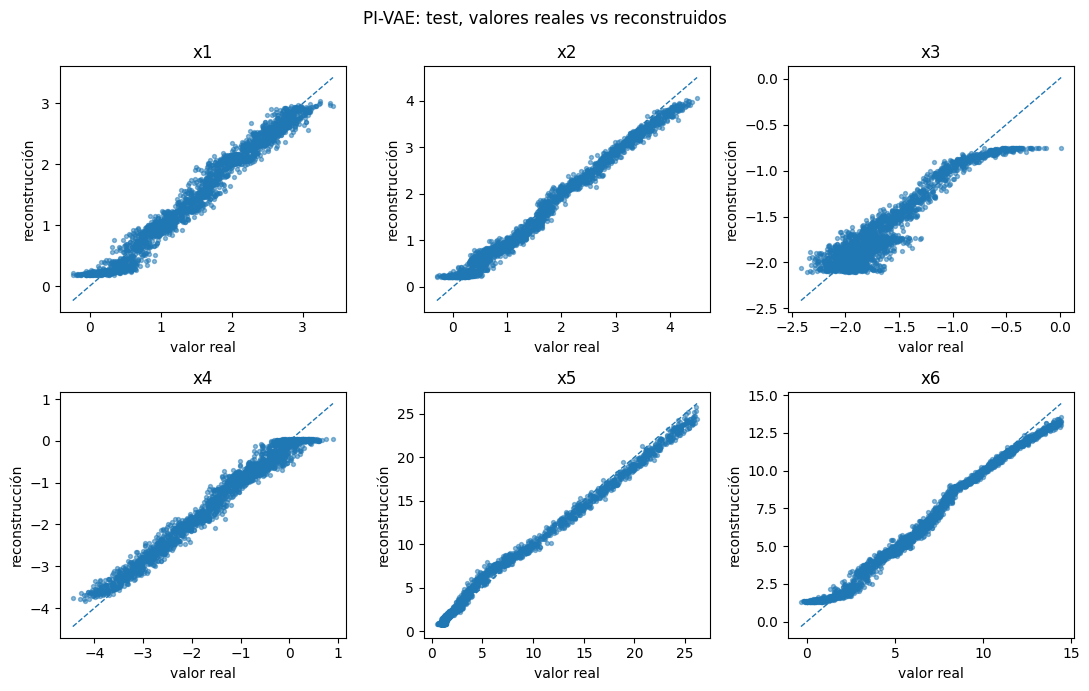

In [33]:
def plot_true_vs_pred(model: VAE, x_norm: torch.Tensor, x_raw: torch.Tensor, title: str) -> None:
    model.eval()
    with torch.no_grad():
        x_hat_raw = unnormalize(model.reconstruct_deterministic(x_norm))

    x_np = x_raw.detach().cpu().numpy()
    xhat_np = x_hat_raw.detach().cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(11, 7))
    axes = axes.ravel()
    for j, ax in enumerate(axes):
        ax.scatter(x_np[:, j], xhat_np[:, j], s=8, alpha=0.5)
        lo = min(x_np[:, j].min(), xhat_np[:, j].min())
        hi = max(x_np[:, j].max(), xhat_np[:, j].max())
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
        ax.set_title(f"x{j+1}")
        ax.set_xlabel("valor real")
        ax.set_ylabel("reconstrucción")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_true_vs_pred(vae_model, X_test, X_test_raw, "VAE: test, valores reales vs reconstruidos")
plot_true_vs_pred(pivae_model, X_test, X_test_raw, "PI-VAE: test, valores reales vs reconstruidos")